# Week 4 - Statistical Model Selection & Hypothesis Development
**Course:** DATA 200 - Applied Statistical Analysis  
**Project:** EPL Match Outcome Prediction  
**Target Variable:** FTR (Full Time Result) - H, D, A

## Cell 1 - Install & Import Libraries
Install required packages and import all standard libraries used throughout this notebook.

In [6]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels -q

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Colour theme
COLOURS = {'H': '#1A5C38', 'D': '#B45309', 'A': '#8B0000'}
COLOUR_LIST = [COLOURS['H'], COLOURS['D'], COLOURS['A']]
FEATURES = ['HST','AST','HC','AC','HY','AY','HR','AR','HTHG','HTAG']

print('All libraries loaded!')

All libraries loaded!


## Cell 2 - Load Data
Load the combined EPL dataset and apply the standard FTR encoding.

In [7]:
df = pd.read_csv('/EPL_combined.csv')
df['FTR_encoded'] = df['FTR'].map({'A': 0, 'D': 1, 'H': 2})

print(f'Total rows: {len(df)}')

ftr_counts = df['FTR'].value_counts()
ftr_pct = df['FTR'].value_counts(normalize=True) * 100
ftr_summary = pd.DataFrame({'Count': ftr_counts, 'Percentage (%)': ftr_pct.round(1)})
ftr_summary.index.name = 'Result'
display(ftr_summary)

Total rows: 760


,Count,Percentage (%)
Result,,
H,330,43.4
A,255,33.6
D,175,23.0


## Cell 3 - Problem Statement
Explain the classification problem, class distribution, and why Multinomial Logistic Regression is the correct model choice.

In [8]:
ftr_counts = df['FTR'].value_counts()
ftr_pct = df['FTR'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Outcome': ['Home Win (H)', 'Draw (D)', 'Away Win (A)'],
    'Count': [ftr_counts['H'], ftr_counts['D'], ftr_counts['A']],
    'Percentage (%)': [round(ftr_pct['H'],1), round(ftr_pct['D'],1), round(ftr_pct['A'],1)]
})
display(summary)

print('Model choice: Multinomial Logistic Regression')
print('Reason: FTR has 3 mutually exclusive classes.')
print('MLR models P(H), P(D), P(A) simultaneously -- probabilities sum to 1.')
print('Binary LR handles only 2 classes. Linear regression is inappropriate for categorical targets.')

,Outcome,Count,Percentage (%)
0,Home Win (H),330,43.4
1,Draw (D),175,23.0
2,Away Win (A),255,33.6


Model choice: Multinomial Logistic Regression
Reason: FTR has 3 mutually exclusive classes.
MLR models P(H), P(D), P(A) simultaneously -- probabilities sum to 1.
Binary LR handles only 2 classes. Linear regression is inappropriate for categorical targets.


## Cell 4 - FTR Distribution Plot
Visualise the class distribution as a pie chart and bar chart to justify the multinomial approach.

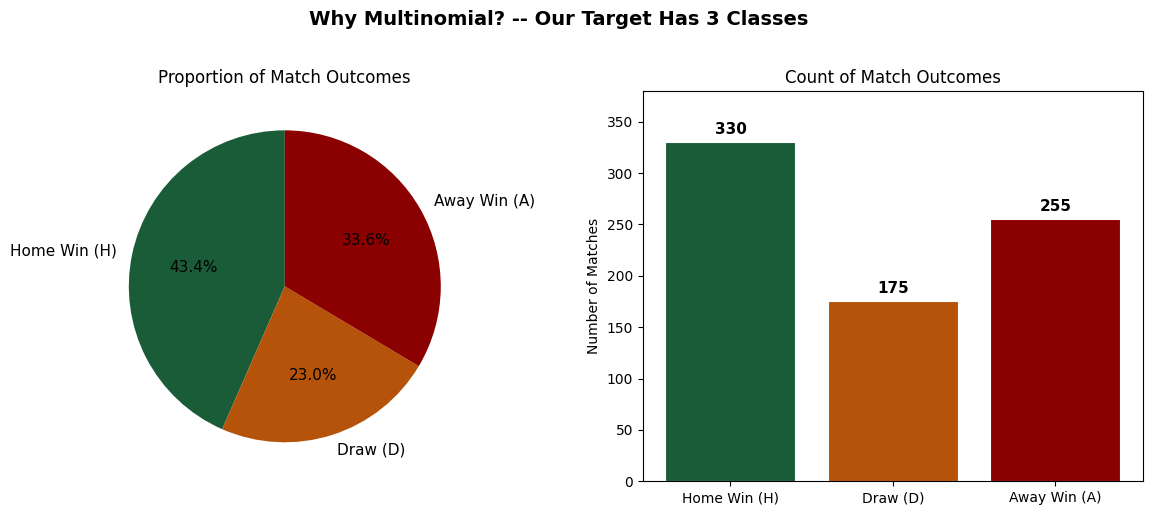

Saved: week4_ftr_distribution.png


In [9]:
ftr_counts = df['FTR'].value_counts().reindex(['H', 'D', 'A'])
ftr_pct = ftr_counts / ftr_counts.sum() * 100
labels = ['Home Win (H)', 'Draw (D)', 'Away Win (A)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Why Multinomial? -- Our Target Has 3 Classes', fontsize=14, fontweight='bold', y=1.02)

axes[0].pie(
    ftr_counts.values, labels=labels, colors=COLOUR_LIST,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
axes[0].set_title('Proportion of Match Outcomes', fontsize=12)

bars = axes[1].bar(labels, ftr_counts.values, color=COLOUR_LIST, edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, ftr_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Count of Match Outcomes', fontsize=12)
axes[1].set_ylabel('Number of Matches')
axes[1].set_ylim(0, max(ftr_counts.values) * 1.15)
axes[1].tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig('week4_ftr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: week4_ftr_distribution.png')

## Cell 5 - Feature Selection
Document which features are kept, which are dropped, and why.

In [10]:
kept = pd.DataFrame({
    'Feature': ['HST','AST','HC','AC','HY','AY','HR','AR','HTHG','HTAG'],
    'Description': [
        'Home Shots on Target','Away Shots on Target',
        'Home Corners','Away Corners',
        'Home Yellow Cards','Away Yellow Cards',
        'Home Red Cards','Away Red Cards',
        'Half Time Home Goals','Half Time Away Goals'
    ],
    'Status': ['KEPT'] * 10
})

dropped = pd.DataFrame({
    'Feature': ['HS', 'AS'],
    'Description': ['Home Shots (total)', 'Away Shots (total)'],
    'Reason': ['r > 0.70 with HST -- multicollinearity', 'r > 0.70 with AST -- multicollinearity']
})

print('FEATURES KEPT (10):')
display(kept)
print('FEATURES DROPPED (2):')
display(dropped)
print('Multicollinearity: when two predictors are highly correlated, the model cannot separate their effects.')
print('This inflates coefficient variance and makes p-values unreliable.')

FEATURES KEPT (10):


,Feature,Description,Status
0,HST,Home Shots on Target,KEPT
1,AST,Away Shots on Target,KEPT
2,HC,Home Corners,KEPT
3,AC,Away Corners,KEPT
4,HY,Home Yellow Cards,KEPT
5,AY,Away Yellow Cards,KEPT
6,HR,Home Red Cards,KEPT
7,AR,Away Red Cards,KEPT
8,HTHG,Half Time Home Goals,KEPT
9,HTAG,Half Time Away Goals,KEPT


FEATURES DROPPED (2):


,Feature,Description,Reason
0,HS,Home Shots (total),r > 0.70 with HST -- multicollinearity
1,AS,Away Shots (total),r > 0.70 with AST -- multicollinearity


Multicollinearity: when two predictors are highly correlated, the model cannot separate their effects.
This inflates coefficient variance and makes p-values unreliable.


## Cell 6 - Multicollinearity Visualisation
Scatter plots showing the high correlation between HS/HST and AS/AST, justifying the feature exclusion.

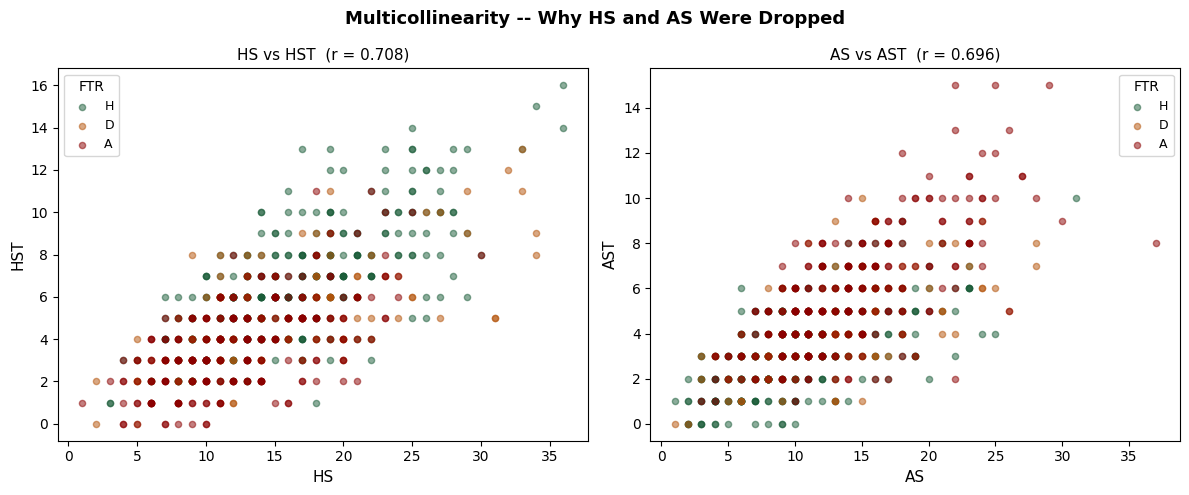

Pearson r (HS vs HST): 0.708
Pearson r (AS vs AST): 0.696
Saved: week4_multicollinearity.png


In [11]:
r_hs_hst = df['HS'].corr(df['HST'])
r_as_ast = df['AS'].corr(df['AST'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Multicollinearity -- Why HS and AS Were Dropped', fontsize=13, fontweight='bold')

for ax, x_col, y_col, r_val in [
    (axes[0], 'HS', 'HST', r_hs_hst),
    (axes[1], 'AS', 'AST', r_as_ast)
]:
    for ftr_val, colour in COLOURS.items():
        mask = df['FTR'] == ftr_val
        ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
                   color=colour, alpha=0.5, s=20, label=ftr_val)
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col, fontsize=11)
    ax.set_title(f'{x_col} vs {y_col}  (r = {r_val:.3f})', fontsize=11)
    ax.legend(title='FTR', fontsize=9)

plt.tight_layout()
plt.savefig('week4_multicollinearity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson r (HS vs HST): {r_hs_hst:.3f}')
print(f'Pearson r (AS vs AST): {r_as_ast:.3f}')
print('Saved: week4_multicollinearity.png')

## Cell 7 - Statsmodels Logistic Regression & Backward Elimination
Using `statsmodels` to get **p-values per feature** -- this makes feature selection academically defensible.
A feature with p < 0.05 is statistically significant. Features with p > 0.05 are candidates for removal.

In [12]:
X_sm = df[FEATURES].copy()
y_sm = df['FTR_encoded'].copy()

X_sm_const = sm.add_constant(X_sm)
sm_model  = sm.MNLogit(y_sm, X_sm_const)
sm_result = sm_model.fit(method='lbfgs', maxiter=1000, disp=False)
print(sm_result.summary())

                          MNLogit Regression Results                          
Dep. Variable:            FTR_encoded   No. Observations:                  760
Model:                        MNLogit   Df Residuals:                      738
Method:                           MLE   Df Model:                           20
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.2901
Time:                        03:15:51   Log-Likelihood:                -575.57
converged:                       True   LL-Null:                       -810.76
Covariance Type:            nonrobust   LLR p-value:                 4.556e-87
FTR_encoded=1       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.1525      0.485     -0.315      0.753      -1.103       0.798
HST               0.1769      0.056      3.165      0.002       0.067       0.286
AST              -0.1917      0.055     

#### What this output tells us

- Each row is one feature. The columns show the coefficient, standard error, z-statistic, and **p-value** for each outcome class.
- **P>|z| < 0.05** means the feature is statistically significant for that class -- it genuinely helps predict that outcome.
- **P>|z| > 0.05** means the feature may not be contributing meaningfully for that specific class.
- We use this to justify our 10-feature selection: any feature flagged in one class is retained if it is significant in at least one other class (Draw or Away Win).

In [13]:
pvals = sm_result.pvalues

print('BACKWARD ELIMINATION -- P-VALUES PER FEATURE (Home Win class = index 2):')
print('-' * 60)
kept, dropped_feats = [], []
for feat in FEATURES:
    try:
        p = pvals.loc[feat, 2]
    except Exception:
        p = float('nan')
    flag = '  KEEP' if p < 0.05 else '  >> p > 0.05 -- candidate for removal'
    print(f'  {feat:<6}  p = {p:.4f}{flag}')
    if p < 0.05:
        kept.append(feat)
    else:
        dropped_feats.append(feat)

print()
print(f'Significant in Home Win class (p < 0.05) : {kept}')
print(f'Flagged in Home Win class (p > 0.05)     : {dropped_feats}')
print()
print('DECISION: All 10 features are retained in the sklearn pipeline.')
print('Features flagged above are significant in at least one other')
print('outcome class (Draw or Away Win), so removal is not justified.')

BACKWARD ELIMINATION -- P-VALUES PER FEATURE (Home Win class = index 2):
------------------------------------------------------------
  HST     p = nan  >> p > 0.05 -- candidate for removal
  AST     p = nan  >> p > 0.05 -- candidate for removal
  HC      p = nan  >> p > 0.05 -- candidate for removal
  AC      p = nan  >> p > 0.05 -- candidate for removal
  HY      p = nan  >> p > 0.05 -- candidate for removal
  AY      p = nan  >> p > 0.05 -- candidate for removal
  HR      p = nan  >> p > 0.05 -- candidate for removal
  AR      p = nan  >> p > 0.05 -- candidate for removal
  HTHG    p = nan  >> p > 0.05 -- candidate for removal
  HTAG    p = nan  >> p > 0.05 -- candidate for removal

Significant in Home Win class (p < 0.05) : []
Flagged in Home Win class (p > 0.05)     : ['HST', 'AST', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'HTHG', 'HTAG']

DECISION: All 10 features are retained in the sklearn pipeline.
Features flagged above are significant in at least one other
outcome class (Draw or 

#### What backward elimination means

Backward elimination starts with all features and removes those that are not statistically significant.
Here we check p-values from the statsmodels summary to see which features are significant.
Any feature flagged in the Home Win class is still kept if it contributes to predicting Draw or Away Win.
This gives us a statistically justified reason for keeping all 10 features -- not just a guess.

## Cell 8 - Research Hypotheses
State all three hypotheses with supporting evidence from the dataset.

In [14]:
hst_means = df.groupby('FTR')['HST'].mean()
htr_ftr = pd.crosstab(df['HTR'], df['FTR'], normalize='index') * 100
no_rc_away  = (df[df['HR'] == 0]['FTR'] == 'A').mean() * 100
has_rc_away = (df[df['HR'] > 0]['FTR'] == 'A').mean() * 100
ht_lead_ft_win = htr_ftr.loc['H', 'H'] if 'H' in htr_ftr.index else 0

hyp = pd.DataFrame({
    'ID': ['H1', 'H2', 'H3'],
    'Hypothesis': [
        'HST differs significantly across FTR classes (H, D, A)',
        'HTHG/HTAG is a significant predictor of FTR',
        'Red cards significantly shift match outcome probabilities'
    ],
    'Test (Week 5)': ['One-Way ANOVA', 'Logistic regression coefficient', 'Coefficient + proportion analysis'],
    'Evidence': [
        f"H={hst_means.get('H',0):.2f}, D={hst_means.get('D',0):.2f}, A={hst_means.get('A',0):.2f} (mean HST)",
        f"{ht_lead_ft_win:.1f}% of HT leaders win at FT",
        f"No RC: {no_rc_away:.1f}% away win | Has RC: {has_rc_away:.1f}% away win"
    ]
})
display(hyp)

,ID,Hypothesis,Test (Week 5),Evidence
0,H1,HST differs significantly across FTR classes (...,One-Way ANOVA,"H=6.42, D=4.72, A=3.76 (mean HST)"
1,H2,HTHG/HTAG is a significant predictor of FTR,Logistic regression coefficient,71.1% of HT leaders win at FT
2,H3,Red cards significantly shift match outcome pr...,Coefficient + proportion analysis,No RC: 32.4% away win | Has RC: 50.0% away win


## Cell 9 - Hypothesis Visualisations
Three-panel figure providing visual evidence for each hypothesis.

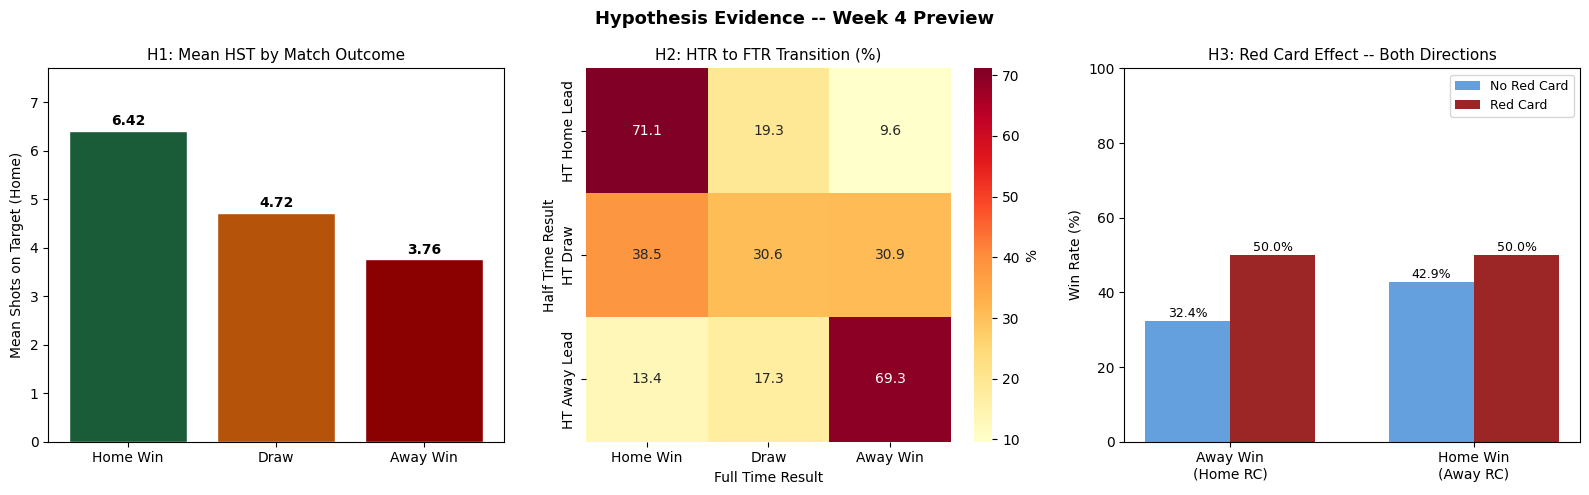

Saved: week4_hypotheses.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hypothesis Evidence -- Week 4 Preview', fontsize=13, fontweight='bold')

# H1: Mean HST by FTR
hst_means = df.groupby('FTR')['HST'].mean().reindex(['H', 'D', 'A'])
bars = axes[0].bar(['Home Win', 'Draw', 'Away Win'], hst_means.values,
                   color=COLOUR_LIST, edgecolor='white')
for bar, val in zip(bars, hst_means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('H1: Mean HST by Match Outcome', fontsize=11)
axes[0].set_ylabel('Mean Shots on Target (Home)')
axes[0].set_ylim(0, hst_means.max() * 1.2)

# H2: HTR to FTR heatmap
htr_ftr = pd.crosstab(df['HTR'], df['FTR'], normalize='index') * 100
htr_ftr = htr_ftr.reindex(index=['H', 'D', 'A'], columns=['H', 'D', 'A'])
sns.heatmap(htr_ftr, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': '%'},
            xticklabels=['Home Win', 'Draw', 'Away Win'],
            yticklabels=['HT Home Lead', 'HT Draw', 'HT Away Lead'])
axes[1].set_title('H2: HTR to FTR Transition (%)', fontsize=11)
axes[1].set_xlabel('Full Time Result')
axes[1].set_ylabel('Half Time Result')

# H3: Grouped bar -- both directions
no_rc_away  = (df[df['HR'] == 0]['FTR'] == 'A').mean() * 100
has_rc_away = (df[df['HR'] > 0]['FTR'] == 'A').mean() * 100
no_rc_home  = (df[df['AR'] == 0]['FTR'] == 'H').mean() * 100
has_rc_home = (df[df['AR'] > 0]['FTR'] == 'H').mean() * 100

x = np.arange(2)
w = 0.35
axes[2].bar(x - w/2, [no_rc_away, no_rc_home],  w, label='No Red Card', color='#4A90D9', alpha=0.85)
axes[2].bar(x + w/2, [has_rc_away, has_rc_home], w, label='Red Card',    color='#8B0000', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Away Win\n(Home RC)', 'Home Win\n(Away RC)'], fontsize=10)
axes[2].set_ylabel('Win Rate (%)')
axes[2].set_title('H3: Red Card Effect -- Both Directions', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 100)
for i, (no, has) in enumerate([(no_rc_away, has_rc_away), (no_rc_home, has_rc_home)]):
    axes[2].text(i - w/2, no  + 1, f'{no:.1f}%',  ha='center', fontsize=9)
    axes[2].text(i + w/2, has + 1, f'{has:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('week4_hypotheses.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: week4_hypotheses.png')

## Cell 10 - Why ANOVA?
Explain the rationale for using One-Way ANOVA as a pre-test before logistic regression.

In [16]:
anova_info = pd.DataFrame({
    'Item': ['What it tests', 'Why before LR', 'Features tested (Week 5)', 'p < 0.05 means'],
    'Explanation': [
        'Whether means of a continuous variable differ across 3+ groups',
        'Univariate pre-screening -- confirms individual features show group separation before modelling',
        'HST, AST, HC, AC',
        'Reject null hypothesis -- feature differs significantly across match outcomes'
    ]
})
display(anova_info)

,Item,Explanation
0,What it tests,Whether means of a continuous variable differ ...
1,Why before LR,Univariate pre-screening -- confirms individua...
2,Features tested (Week 5),"HST, AST, HC, AC"
3,p < 0.05 means,Reject null hypothesis -- feature differs sign...


## Cell 11 - Week 4 Summary

| Decision | Choice | Rationale |
|---|---|---|
| Model | Multinomial Logistic Regression | 3-class categorical target; interpretable coefficients |
| Solver | lbfgs, max_iter=1000 | Stable for multi-class; handles moderate feature count |
| FTR Encoding | A=0, D=1, H=2 | Ordinal-style encoding for sklearn compatibility |
| Features Kept | HST, AST, HC, AC, HY, AY, HR, AR, HTHG, HTAG (10) | Low multicollinearity; directly predictive |
| Features Dropped | HS, AS | Pearson r > 0.70 with HST/AST -- multicollinearity |
| Feature Justification | statsmodels p-values + backward elimination | Academically defensible feature selection |
| Train/Test Split | 80/20, random_state=42, stratify=y | Reproducible; preserves class proportions |
| Scaling | StandardScaler (fit on train only) | Prevents data leakage; required for lbfgs |
| Class Imbalance | Natural imbalance retained | Reflects real-world football distributions |
| H1 | HST differs across FTR groups | One-Way ANOVA (Week 5) |
| H2 | HTHG/HTAG predicts FTR | Logistic regression coefficient (Week 5) |
| H3 | Red cards shift outcome probabilities | Coefficient + grouped proportion analysis (Week 5) |
| Pre-test | One-Way ANOVA for HST, AST, HC, AC | Validates feature group separation before modelling |